Saving my version of Strong Cesium gaussian three curves - Sheet1 (8).csv to my version of Strong Cesium gaussian three curves - Sheet1 (8) (5).csv
File uploaded: my version of Strong Cesium gaussian three curves - Sheet1 (8) (5).csv
Columns in the file: ['channel_18_deg', '18_degrees', 'channel_20_deg', '20_degrees', 'channel_25_deg', '25_degrees', 'channel_30_deg', '30_degrees', 'channel_40_deg', '40_degrees', 'channel_50_deg', '50_degrees', 'channel_60_deg', '60_degrees', 'channel_70_deg', '70_degrees', 'channel_80_deg', '80_degrees', 'channel_90_deg', '90_degrees', 'channel_100_deg', '100_degrees', 'channel_110_deg', '110_degrees', 'channel_0_deg_no_scatter', '0_deg_no_scatter', 'channel_0_deg_scatter', '0_deg_scatter', 'Unnamed: 28', 'channel_0_deg(entire)', '0_deg_no_scatter(entire)', '0° ( Scatter)_entire', 'Unnamed: 32', 'Large Aluminum', 'theta (degrees)', 'Y(theta)', 'sigma_Y(theta)', 'dσ/dΩ (Experimental)', 'sigma_dσ/dΩ (Experimental)', 'dσ/dΩ (K_N)', 'dσ/dΩ (Thompson )', 'U

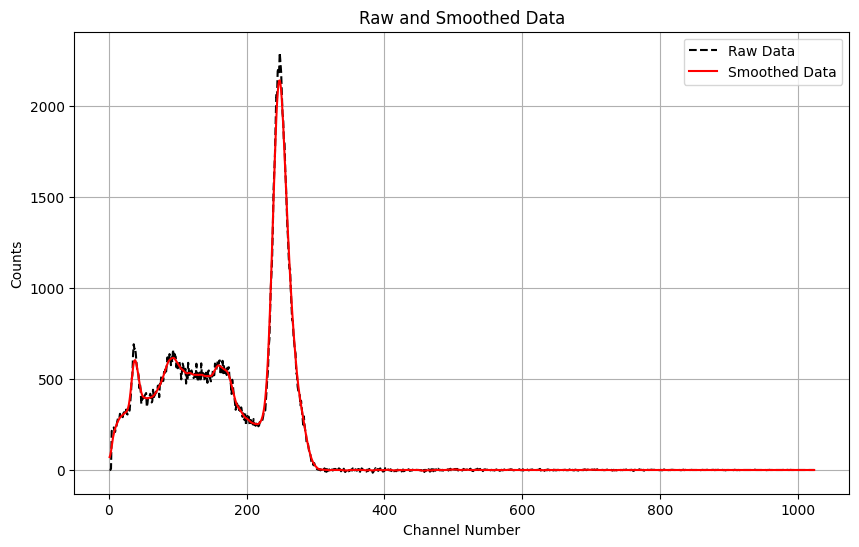

Total area under the curve (numerical) = 165041.0084 ± 3.4732e+00


<ipython-input-9-b9070209d399>:56: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  area, error = quad(fitting_function, split_points[i], split_points[i + 1], limit=100, epsabs=1e-6, epsrel=1e-6)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad  # For numerical integration
from scipy.ndimage import gaussian_filter1d  # For smoothing
import pandas as pd
from google.colab import files

# Read data from CSV file
def read_data():
    try:
        # Prompt user to upload the file
        uploaded = files.upload()

        # Read the first uploaded file
        for filename in uploaded.keys():
            print(f"File uploaded: {filename}")
            data = pd.read_csv(filename)
            print(f"Columns in the file: {data.columns.tolist()}")

            # Ensure the necessary columns exist
            required_columns = ['channel_0_deg(entire)', '0° ( Scatter)_entire']
            if not all(col in data.columns for col in required_columns):
                raise ValueError(f"The CSV file must contain the following columns: {required_columns}")

            # Extract the necessary columns
            channel_number = data['channel_0_deg(entire)'].to_numpy()
            counts = data['0° ( Scatter)_entire'].to_numpy()

            return channel_number, counts
    except Exception as e:
        print(f"Error reading file: {e}")
        return None, None

# Filter out NaN and Inf values from the data
def clean_data(channel_number, counts):
    mask = np.isfinite(channel_number) & np.isfinite(counts)
    return channel_number[mask], counts[mask]

# Apply smoothing to reduce noise
def smooth_data(counts, sigma=3):
    return gaussian_filter1d(counts, sigma=sigma)

# Numerical integration function (splitting the range)
def integrate_data(channel_number, counts):
    # Interpolation function to fit smoothed data
    def fitting_function(x):
        # Linear interpolation between discrete data points
        return np.interp(x, channel_number, counts)

    # Split the range into smaller intervals
    split_points = np.linspace(min(channel_number), max(channel_number), num=5)
    total_area = 0
    total_error = 0

    for i in range(len(split_points) - 1):
        area, error = quad(fitting_function, split_points[i], split_points[i + 1], limit=100, epsabs=1e-6, epsrel=1e-6)
        total_area += area
        total_error += error

    return total_area, total_error

# Load the data from the file
channel_number, counts = read_data()

if channel_number is not None and counts is not None:
    # Clean the data
    channel_number, counts = clean_data(channel_number, counts)

    if len(channel_number) == 0 or len(counts) == 0:
        print("Data contains only NaNs or Infs after cleaning. Please check your file.")
    else:
        # Apply smoothing to the counts data
        smoothed_counts = smooth_data(counts, sigma=3)

        # Plot the raw and smoothed data
        plt.figure(figsize=(10, 6))
        plt.plot(channel_number, counts, 'k--', label='Raw Data')
        plt.plot(channel_number, smoothed_counts, 'r-', label='Smoothed Data')
        plt.xlabel('Channel Number')
        plt.ylabel('Counts')
        plt.title('Raw and Smoothed Data')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Perform numerical integration
        area_total, area_total_error = integrate_data(channel_number, smoothed_counts)

        # Print the total area and uncertainty
        print(f"Total area under the curve (numerical) = {area_total:.4f} ± {area_total_error:.4e}")